In [32]:
import os
import matplotlib.pyplot as plt


from sampo_api import contractor
from scripts.wg_converter import WorkGraphConverter, ProjectConverter
from scripts.valid import run_heuristic, resource_profiles, check_feasibility
from scripts.metrics import distance_matrices

from sampo.schemas.graph import WorkGraph


plt.rcParams['axes.grid'] = False

def read_file(path='wgs/small_synth', file='wg_9', contractors_N=5):  
    wg = WorkGraph.loadf(path, file)
    contractors = contractor(N = contractors_N)
    conv = WorkGraphConverter()
    data = conv.convert(wg, contractors)['rcpsp_data']
    return data

# def get_solve(files, base_path, data):

def validate_structures(base_path):
    data = read_file()
    res = []
    files = [f for f in os.listdir(base_path) if f != 'Steps']
    for file in files:
        try:
            schedule, _, resource_usage, job_usage, _  = run_heuristic(base_path, file, data)
            name = (file , file.split(' ')[-1])
        except:
            continue
        if not check_feasibility(schedule, job_usage, resource_usage, data):
            continue
        resource_profile = resource_profiles(schedule, resource_usage)
        res.append((name, resource_profile, schedule))

    print (f'Originality after test case:  {round( len(res) * 100 / len(files) )} %')
    heuristics, D_contractor, D_interval, D_resource, D_order = distance_matrices(res)
    D_total = D_contractor + D_interval + D_resource + D_order
    return heuristics, D_contractor, D_interval, D_resource, D_order, D_total

    

No rcpsp_solver function found in the code for method original_heuristics.json
Error executing code for method original_heuristics.json: local variable 'schedule' referenced before assignment
Error executing code for method Minimum Total Float Rule (TF): local variable '_enforce_time_limit' referenced before assignment
Error executing code for method Minimum Number of Successors Rule (MNS): Deadlock detected: no feasible schedule possible
Originality after test case:  73 %
Originality after matrix filter:  100 %
Acceptable for populations: (LFT), (MS), (SPT), (MRD), (LPT), (MXS), (MRS), (EST).


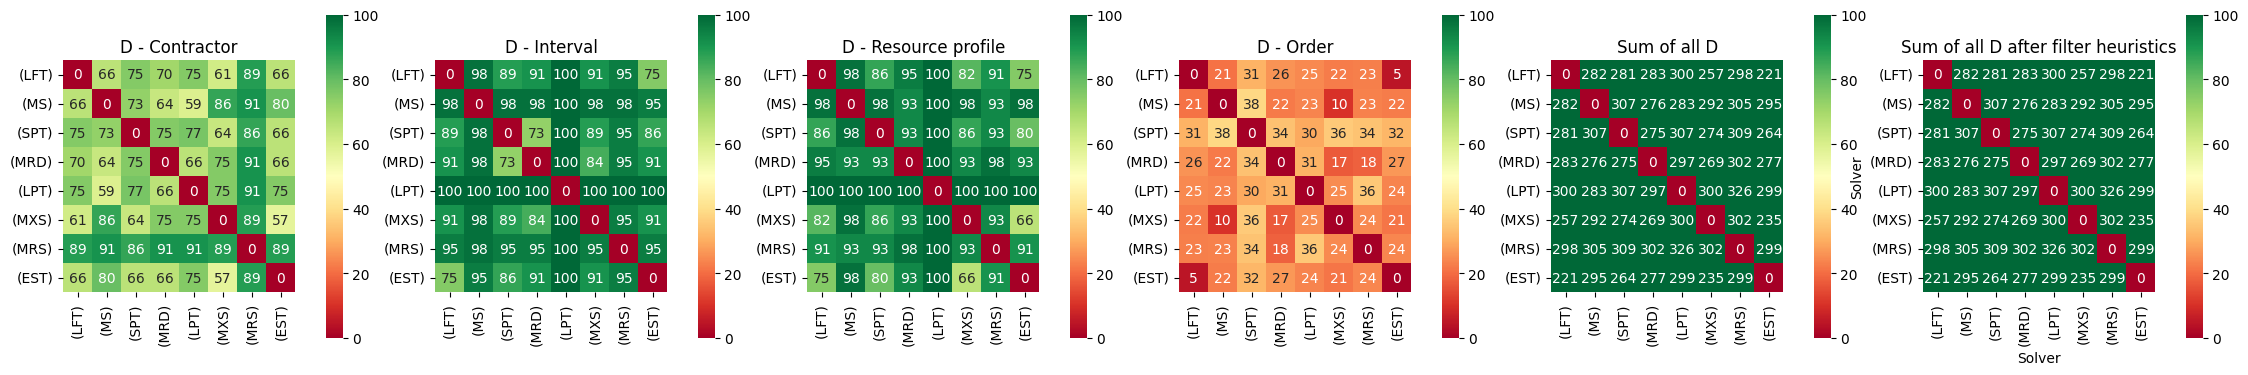

In [33]:
from scripts.valid import *
from collections import defaultdict
from scripts.wg_converter import *
from sampo_api import *
from scripts.metrics import distance_matrices

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json 


def save_filter(path, names):
    with open(os.path.join(path, 'original_heuristics.json'), "w", encoding="utf-8") as f:
        json.dump(names, f, ensure_ascii=False, indent=2)

def plot_heatmap(axes, metrics, labels, orig_labels, 
                 titles = ['D - Contractor', 'D - Interval', 'D - Resource profile', 'D - Order', 
          'Sum of all D', 'Sum of all D after filter heuristics'], vmin=0.0, vmax=100.0):
    for i, metric in enumerate(metrics):

        labels = orig_labels if i == 5 else labels
            
        sns.heatmap(metric * 100, 
                    xticklabels=labels, yticklabels=labels, cmap="RdYlGn", 
                    vmin=vmin, vmax=vmax, annot=True,
                      fmt=".0f", square=True, ax=axes[i], 
                    cbar_kws={"shrink": 0.3, "pad": 0.1})
        
        axes[i].set_title(titles[i])
        plt.xlabel("Solver")
        plt.ylabel("Solver")
        
def get_filtered_row_indices(D):
    n = D.shape[0]
    # маска внедиагональных элементов
    mask_non_diag = ~np.eye(n, dtype=bool)
    # маска внедиагональных нулей (с учётом float)
    mask_offdiag_zero = D!= 0 & mask_non_diag
    keys = [tuple(row.astype(int)) for row in mask_offdiag_zero]
    seen = set()
    keep = []
    for i in range(n):
        key = keys[i]
        if key not in seen:
            keep.append(i)
            seen.add(key)
    return set(keep)
def estimate_algorithms(D_total, solvers):
    original_idx  = get_filtered_row_indices(D_total)
    original_heuristics = []
    for i, s in enumerate(solvers):
        if i in original_idx:
            original_heuristics.append(s)

    print (f'Originality after matrix filter:  {round( len(original_heuristics) * 100 / len(solvers) )} %')
    print('Acceptable for populations: ' + ', '.join(original_heuristics) +'.')
    return original_idx, original_heuristics


# deepseek_reasoner_control
# Папка для проверок сгенерированных скриптов и сэмпл (проект для теста)
# gpt_oss_120b, deepseek_reasoner, deepseek_chat
base_path = 'Heuristics/gpt_oss_120b'
heuristics, D_contractor, D_interval, D_resource, D_order, D_total = validate_structures(base_path)
idx, original_heuristics = estimate_algorithms(D_total, heuristics)

metrics = (D_contractor, D_interval, D_resource, D_order,
   D_total, D_total[list(idx)][:, list(idx)])

fig, axes = plt.subplots(ncols=6, nrows=1, figsize = (28,14) )

plot_heatmap(axes, metrics, heuristics, original_heuristics)

save_filter(base_path, original_heuristics)

fig.savefig("Images/D_gpt_oss.png", dpi=150, bbox_inches="tight")




In [34]:
original_heuristics

['(LFT)', '(MS)', '(SPT)', '(MRD)', '(LPT)', '(MXS)', '(MRS)', '(EST)']

In [35]:
# def validate_structures(base_path):
#     data = read_file()
#     res = []
#     files = [f for f in os.listdir(base_path) if f != 'Steps']
#     for file in files:
#         schedule, _, resource_usage, _  = run_heuristic(base_path, file, data)
#         print(resource_usage)
#         name = file.split(' ')[-1]
#         resource_profile = resource_profiles(schedule,resource_usage)
#         res.append( (name, resource_profile, schedule) )

#     heuristics, D_contractor, D_interval, D_resource, D_order = distance_matrices(res)
#     D_total = D_contractor + D_interval + D_resource + D_order
#     return heuristics, D_contractor, D_interval, D_resource, D_order, D_total


# validate_structures(base_path)

# Проверка 1 - Сравнения LLM-сгенерированных эвристик между собой 
Обозначим множество всех решателей через $S$, а проект через $J$.
Каждому решателю $A \in S$ сопоставлено решение (расписание) по всем
ограничениям и переменным проекта $J$.

Для пары решений $A, B \in S$ введём метрику расстояния $d(A,B)$ как
сумму четырёх компонент:

$$
d(A,B)
=
d_{\text{contractor}}(A,B)
+
d_{\text{interval}}(A,B)
+
d_{\text{resource}}(A,B)
+
d_{\text{order}}(A,B).
$$

Поскольку все решатели рассматривают один и тот же проект $J$, 
множество работ (переменных/активностей) одинаково для всех решений.
Тогда для любой пары решателей $A,B \in S$:

$$
J_A = J_B = J,
\qquad
J_{AB} = J.
$$

1. Доля различий по подрядчикам

$$
d_{\text{contractor}}(A,B)
=
\frac{1}{| J |}
\sum_{j \in J}
\mathbf{1}\!\left[
c_{A,j} \neq c_{B,j}
\right].
$$

2. Доля различий по интервалам

$$
d_{\text{interval}}(A,B)
=
\frac{1}{| J |}
\sum_{j \in J}
\mathbf{1}\!\left[
\left(t^{\text{start}}_{A,j}, t^{\text{end}}_{A,j}\right)
\neq
\left(t^{\text{start}}_{B,j}, t^{\text{end}}_{B,j}\right)
\right].
$$

3. Доля различий по ресурсным профилям

$$
d_{\text{resource}}(A,B)
=
\frac{1}{| J |}
\sum_{j \in J}
\mathbf{1}\!\left[
\text{res\_profile}_A(j)
\neq
\text{res\_profile}_B(j)
\right].
$$

4. Доля различий по относительному порядку работ (на основе коэффицента Кендалла)

Сначала введём функцию знака:

$$
\operatorname{sgn}(x) =
\begin{cases}
-1, & x < 0,\\
0, & x = 0,\\
1, & x > 0.
\end{cases}
$$

Тогда

$$
d_{\text{order}}(A,B)
=
\frac{1}{\binom{| J |}{2}}
\sum_{\substack{i,j \in J \\ i < j}}
\mathbf{1}\!\left[
\operatorname{sgn}\!\bigl(t^{\text{start}}_{A,i} - t^{\text{start}}_{A,j}\bigr)
\neq
\operatorname{sgn}\!\bigl(t^{\text{start}}_{B,i} - t^{\text{start}}_{B,j}\bigr)
\right].
$$  

1-3 метрики на основе метрики Хэмминга

# Estimate 0  - GAP с начальной популяцией из SAMPO

In [37]:
from sampo_api import *
from sampo.scheduler.genetic.operators import TimeFitness
from scripts.valid import *


class Evaluator():
    def __init__(self, work_graph, contractors, f = TimeFitness()):
        self.toolbox = create_mvp_toolbox(work_graph, contractors)
        self.fitness_func = f
    def makespan(self, chromosome):
        makespan = self.fitness_func.evaluate(chromosome, evaluator=self.toolbox.evaluate_chromosome)[0]
        return makespan

        

def estimate_llm_heuristics(filter, base_path, 
                            project_conv, data, 
                            eval):
    
    files = [f for f in os.listdir(base_path) if f not in ('Steps', 'original_heuristics.json')]
    makespan_list = []
    for file in files:
        name = file.split(' ')[-1]
        if name not in filter: 
            continue
        schedule, order, _, job_usage, makespan  = run_heuristic(base_path, file, data)
        try:
            schedule_obj = project_conv.to_schedule(schedule, order, job_usage, makespan)
            chromosome = project_conv.output_to_chromosome(schedule, order, job_usage, makespan)
        except: 
            continue
        if validate_schedule_bool(schedule_obj, project_conv.work_graph, list(project_conv.contractors.values()),
                                   spec = ScheduleSpec()) \
            and makespan == eval.makespan(chromosome):

            makespan_list.append(makespan)
            
    return makespan_list


#def compare_sampo()

def estimate_sampo_population(wg, contractors, eval):
    init_choromosome = first_population(wg, contractors)
    makespan_list = [eval.makespan(chrom) for (_, (chrom, _, _)) in init_choromosome.items()]
    makespan_list.sort()
    return makespan_list

def run_experiment(base_path, filter, wg_path='wgs/small_synth'):
    contractors = contractor(N=5)
    result = []
    for f in os.listdir(wg_path):
        row = {}
        wg = WorkGraph.loadf(wg_path, f[:-5])
        data = read_file(file=f[:-5])
        #
        project_conv = ProjectConverter(wg, contractors)
        evaluator = Evaluator(wg, contractors)
        #

        sampo_population = estimate_sampo_population(wg, contractors, evaluator)
        llm_population = estimate_llm_heuristics(filter, base_path, project_conv, data, evaluator)
        #
        row['wg_name'] = f[:-5]
        row['SAMPO_P_min_makespan'] = min(sampo_population)
        row['SAMPO_P_mean_makespan'] = sum(sampo_population) / len(sampo_population)
        row['LLM_feasibility'] = len(llm_population) / len(filter)
        row['LLM_P_min_makespan'] = min(llm_population)
        row['LLM_P_mean_makespan'] = sum(llm_population) / len(llm_population)
        extended_population = sampo_population + llm_population
        row['E_P_min_makespan'] = min(extended_population)
        row['E_P_mean_makespan'] = sum(extended_population) / len(extended_population)
        row['LLM_best'] =  row['LLM_P_min_makespan'] < row['SAMPO_P_min_makespan']

        result.append(row)
    return result

model_generate = [
                  'gpt_5.4_nano', 
                  'gemini_3_flash_preview',
                  'gpt_oss_120b', 
                  'deepseek_reasoner', 
                  'deepseek_chat',
                  'claude_haiku_4.5',
                  'claude_sonnet_4.6'
]

arr = []
for model in model_generate:
    base_path = os.path.join('Heuristics', model)
    # Add check original heuristics 
    heuristics, D_contractor, D_interval, D_resource, D_order, D_total = validate_structures(base_path)
    print(f'{model}, total generated heuristics: {len(heuristics)} ')
    idx, original_heuristics = estimate_algorithms(D_total, heuristics)
    
    result = run_experiment(base_path, original_heuristics)
    result_df = pd.DataFrame(result)
    result_df['LLM_used'] = model
    arr.append(result_df)

df = pd.concat(arr)
df['% shift'] = np.where(df['LLM_best'] == True, 
                        round(df['SAMPO_P_min_makespan']  * 100/ df['LLM_P_min_makespan']) - 100,
                        0) 


    

Error executing code for method Most Critical Path Priority Rule (MCP): Wall-clock time limit exceeded (10 seconds).
No rcpsp_solver function found in the code for method original_heuristics.json
Error executing code for method original_heuristics.json: local variable 'schedule' referenced before assignment
Originality after test case:  55 %
gpt_5.4_nano, total generated heuristics: 6 
Originality after matrix filter:  100 %
Acceptable for populations: (LPT), (MSP), (PGS), (LSP), (SSGS), (EFT).
No rcpsp_solver function found in the code for method original_heuristics.json
Error executing code for method original_heuristics.json: local variable 'schedule' referenced before assignment
Error executing code for method Earliest Finish Time Priority Rule (EFT): Solver exceeded 10s limit
Originality after test case:  82 %
gemini_3_flash_preview, total generated heuristics: 9 
Originality after matrix filter:  100 %
Acceptable for populations: (LPT), (LST), (PGS), (SPT), (GRD), (MSL), (MSN), (

In [52]:
df

,wg_name,SAMPO_P_min_makespan,SAMPO_P_mean_makespan,LLM_feasibility,LLM_P_min_makespan,LLM_P_mean_makespan,E_P_min_makespan,E_P_mean_makespan,LLM_best,LLM_used,% shift
0,wg_5,72,92.428571,0.833333,92,110.800000,72,100.083333,False,gpt_5.4_nano,0.0
1,wg_29,69,91.428571,0.833333,71,114.000000,69,100.833333,False,gpt_5.4_nano,0.0
2,wg_13,69,88.428571,1.000000,83,227.500000,69,152.615385,False,gpt_5.4_nano,0.0
3,wg_44,68,85.142857,0.833333,64,83.600000,64,84.500000,True,gpt_5.4_nano,6.0
4,wg_9,59,92.000000,1.000000,90,211.666667,59,147.230769,False,gpt_5.4_nano,0.0
...,...,...,...,...,...,...,...,...,...,...,...
44,wg_26,78,107.285714,1.000000,88,127.909091,78,119.888889,False,claude_sonnet_4.6,0.0
45,wg_30,78,103.857143,1.000000,67,152.727273,67,133.722222,True,claude_sonnet_4.6,16.0
46,wg_6,73,94.857143,1.000000,79,110.000000,73,104.111111,False,claude_sonnet_4.6,0.0
47,wg_10,77,92.000000,1.000000,78,96.909091,77,95.000000,False,claude_sonnet_4.6,0.0


In [53]:
# # wg = WorkGraph.loadf(wg_path, f[:-5])
# # data = read_file(file=f[:-5])
# schedule, order, _, job_usage, makespan  = run_heuristic('Heuristics/gpt_oss_120b', 'Minimum Earliest Start Time Rule (EST)', read_file())

# schedule

# 'cd613e30-d8f1-6adf-91b7-584a2265b1f5' in order

In [54]:
df = pd.concat(arr)

df['% shift'] = np.where(df['LLM_best'] == True, 
                        round(df['SAMPO_P_min_makespan']  * 100/ df['LLM_P_min_makespan']) - 100,
                        0) 

df[df['LLM_best'] == True].groupby('LLM_used')['% shift'].agg(['min', 'max','count'])


# Всего 49 тестовых кейсов

,min,max,count
LLM_used,,,
claude_haiku_4.5,1.0,24.0,8
claude_sonnet_4.6,1.0,38.0,19
deepseek_chat,1.0,28.0,12
deepseek_reasoner,1.0,27.0,12
gemini_3_flash_preview,1.0,48.0,11
gpt_5.4_nano,3.0,26.0,7
gpt_oss_120b,1.0,28.0,8


In [55]:
#df['LLM_best'] = df['LLM_P_min_makespan'] < df['SAMPO_P_min_makespan']

In [56]:
name_dict = {'min' : 'Min gain', 'max' : 'Max gain', 'count' : 'Makespan improved (unique ids)'}

res_df = pd.concat(
    [
    df.groupby('LLM_used')['LLM_P_mean_makespan'].mean().rename('Mean makespan'),
    round(df.groupby('LLM_used')['LLM_feasibility'].mean() * 100, 1).rename('Feasibility'),
    round(df.groupby('LLM_used')['LLM_feasibility'].std() * 100, 1).rename('Feasibility_std'),
    df[df['LLM_best'] == True].groupby('LLM_used')['% shift'].agg(['min', 'max','count']).rename(name_dict, axis=1),
    round(df.groupby('LLM_used').LLM_best.mean() * 100, 1).rename('% Improved'),
     ], axis=1).T

round(res_df, 1)



LLM_used,claude_haiku_4.5,claude_sonnet_4.6,deepseek_chat,deepseek_reasoner,gemini_3_flash_preview,gpt_5.4_nano,gpt_oss_120b
Mean makespan,147.7,123.6,125.8,117.1,124.7,174.8,303.9
Feasibility,71.1,100.0,100.0,100.0,100.0,89.8,87.5
Feasibility_std,7.4,0.0,0.0,0.0,0.0,9.5,0.0
Min gain,1.0,1.0,1.0,1.0,1.0,3.0,1.0
Max gain,24.0,38.0,28.0,27.0,48.0,26.0,28.0
Makespan improved (unique ids),8.0,19.0,12.0,12.0,11.0,7.0,8.0
% Improved,16.3,38.8,24.5,24.5,22.4,14.3,16.3


In [43]:
total_gap_all_models = round( np.mean( np.where( df.groupby('wg_name').LLM_best.sum() > 0, 1, 0) * 100 ) )
print(total_gap_all_models, '% от всех задач, все модели в совокупности хоть раз смогли понизить makespan от HEFT эвристик')

53 % от всех задач, все модели в совокупности хоть раз смогли понизить makespan от HEFT эвристик


In [44]:
df.pivot_table(
    index='wg_name',
    columns='LLM_used',
    values='LLM_best',
    aggfunc=lambda x: any(x) 
)

LLM_used,claude_haiku_4.5,claude_sonnet_4.6,deepseek_chat,deepseek_reasoner,gemini_3_flash_preview,gpt_5.4_nano,gpt_oss_120b
wg_name,,,,,,,
wg_10,True,False,True,True,False,False,True
wg_11,False,False,False,False,False,False,False
wg_12,False,False,False,False,False,False,False
wg_13,False,True,False,True,False,False,False
wg_14,False,False,False,False,False,False,False
wg_15,False,False,False,False,False,False,False
wg_16,False,False,False,False,False,False,False
wg_17,False,False,False,False,False,False,False
wg_18,False,True,True,True,False,True,True


In [45]:
df.query('wg_name == "wg_42"')


,wg_name,SAMPO_P_min_makespan,SAMPO_P_mean_makespan,LLM_feasibility,LLM_P_min_makespan,LLM_P_mean_makespan,E_P_min_makespan,E_P_mean_makespan,LLM_best,LLM_used,% shift
22,wg_42,69,92.571429,1.000000,62,199.500000,62,141.923077,True,gpt_5.4_nano,11.0
22,wg_42,69,92.571429,1.000000,70,107.888889,69,101.187500,False,gemini_3_flash_preview,0.0
22,wg_42,69,92.571429,0.875000,67,259.285714,67,175.928571,True,gpt_oss_120b,3.0
22,wg_42,69,92.571429,1.000000,75,109.000000,69,99.416667,False,deepseek_reasoner,0.0
22,wg_42,69,92.571429,1.000000,67,94.111111,67,93.437500,True,deepseek_chat,3.0
22,wg_42,69,92.571429,0.666667,67,84.250000,67,89.545455,True,claude_haiku_4.5,3.0
22,wg_42,69,92.571429,1.000000,62,91.363636,62,91.833333,True,claude_sonnet_4.6,11.0


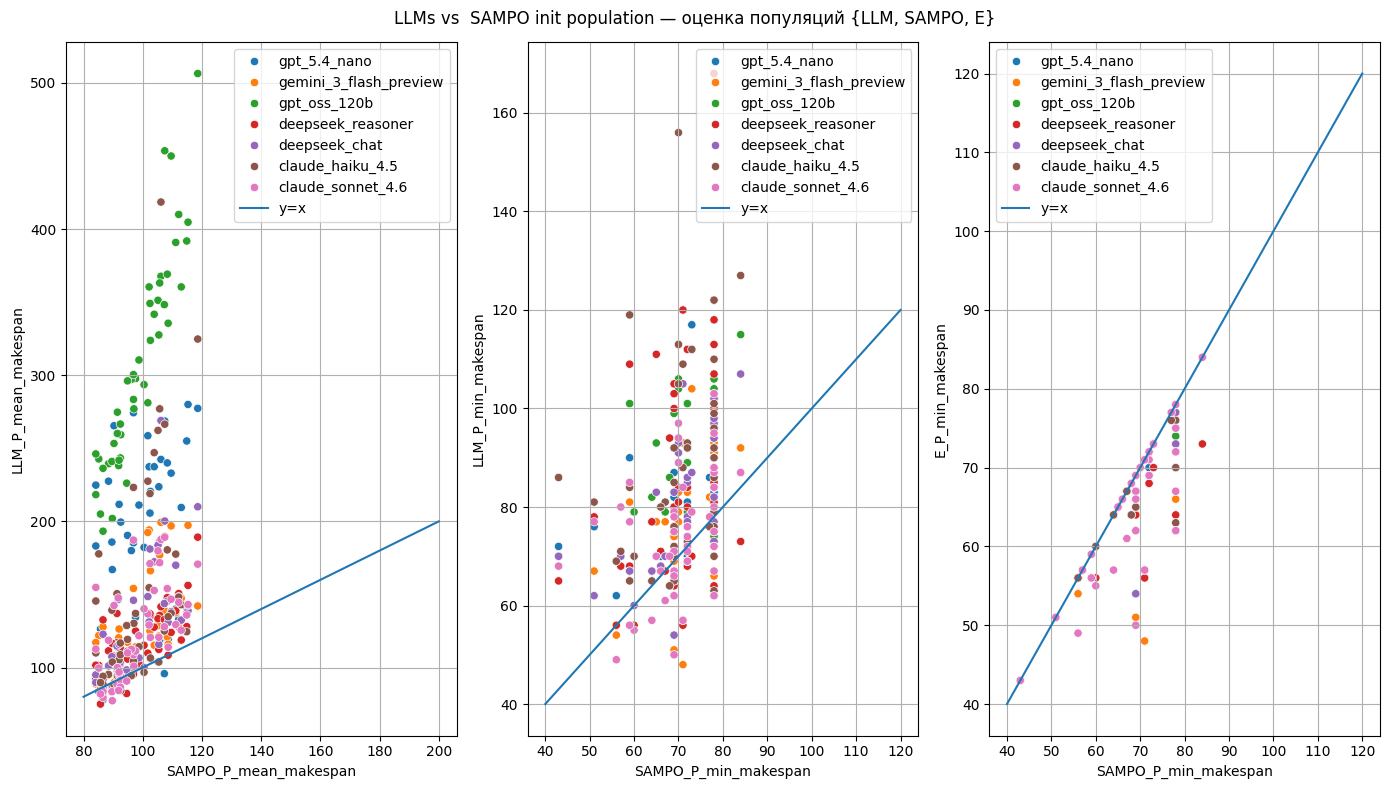

In [46]:
import seaborn as sns
plt.rcParams['axes.grid'] = True
fig, axes = plt.subplots(1, 3, figsize=(14, 8),)

fig.suptitle('LLMs vs  SAMPO init population \u2014 оценка популяций {LLM, SAMPO, E}' )

sns.scatterplot(data=df, x ='SAMPO_P_mean_makespan', y='LLM_P_mean_makespan',hue='LLM_used', ax=axes[0],)
sns.lineplot(x = [80, 200], y =[80, 200], ax=axes[0], label='y=x')

sns.scatterplot(data=df, x ='SAMPO_P_min_makespan', y='LLM_P_min_makespan', hue='LLM_used', ax=axes[1])
sns.lineplot(x = [40, 120], y =[40, 120], ax=axes[1],label='y=x')

sns.scatterplot(data=df, x ='SAMPO_P_min_makespan', y='E_P_min_makespan', hue='LLM_used', ax=axes[2],)
sns.lineplot(x = [40, 120], y =[40, 120], ax=axes[2],label='y=x')
#sns.lineplot(x = [20, 120], y =[10, 85], ax=axes[2],label='y=1/2x')



plt.tight_layout()

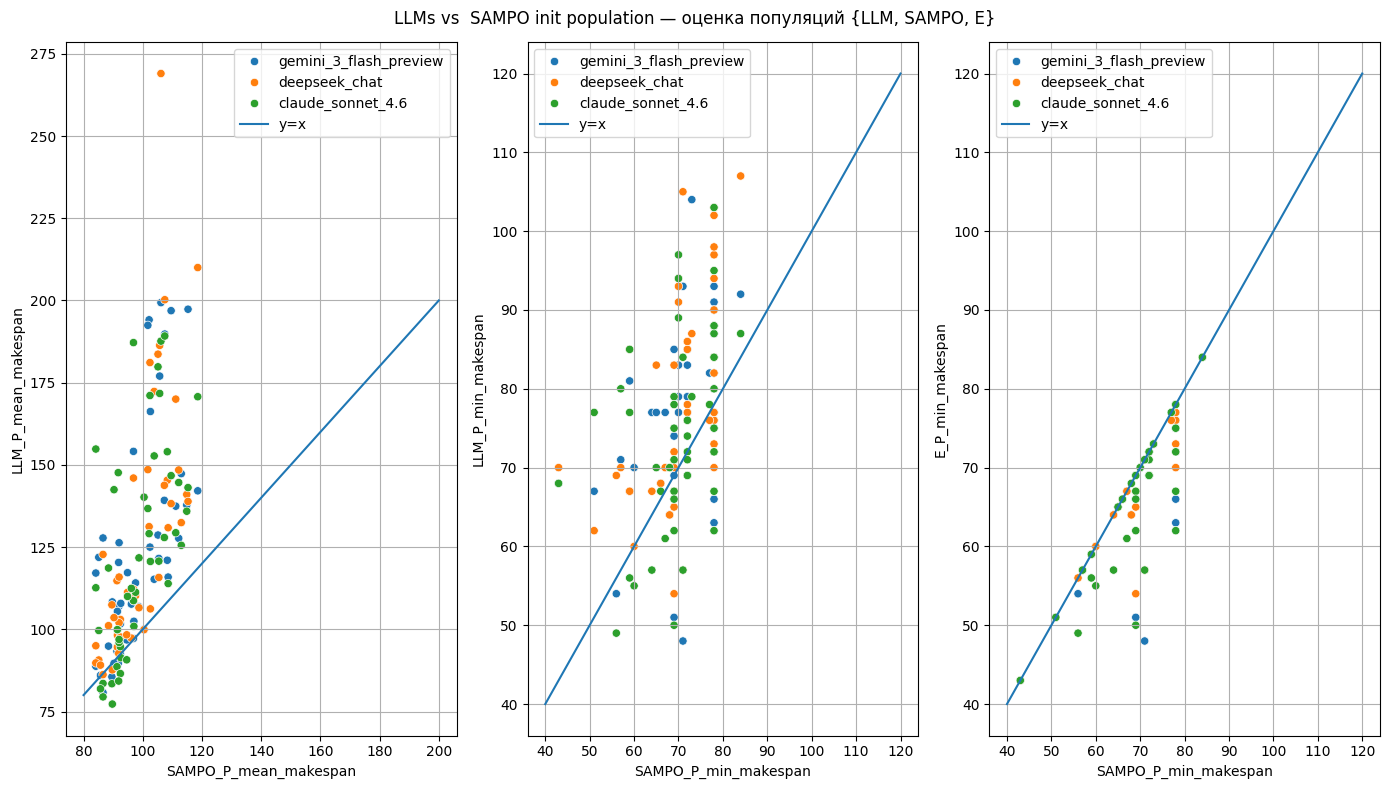

In [47]:
import seaborn as sns

df_best = df.query('LLM_used.isin(["claude_sonnet_4.6", "deepseek_chat", "gemini_3_flash_preview"])')

plt.rcParams['axes.grid'] = True
fig, axes = plt.subplots(1, 3, figsize=(14, 8),)

fig.suptitle('LLMs vs  SAMPO init population \u2014 оценка популяций {LLM, SAMPO, E}' )

sns.scatterplot(data=df_best, x ='SAMPO_P_mean_makespan', y='LLM_P_mean_makespan',hue='LLM_used', ax=axes[0],)
sns.lineplot(x = [80, 200], y =[80, 200], ax=axes[0], label='y=x')

sns.scatterplot(data=df_best, x ='SAMPO_P_min_makespan', y='LLM_P_min_makespan', hue='LLM_used', ax=axes[1])
sns.lineplot(x = [40, 120], y =[40, 120], ax=axes[1],label='y=x')

sns.scatterplot(data=df_best, x ='SAMPO_P_min_makespan', y='E_P_min_makespan', hue='LLM_used', ax=axes[2],)
sns.lineplot(x = [40, 120], y =[40, 120], ax=axes[2],label='y=x')
#sns.lineplot(x = [20, 120], y =[10, 85], ax=axes[2],label='y=1/2x')



plt.tight_layout()

# Time estimate SAMPO vs Gen Heuristics

In [48]:
# def estimate_llm_heuristics(filter, wg, 
#                             contractors, 
#                             base_path, project_conv, data):
    
#     init_choromosome = first_population(wg, contractors)
#     toolbox = create_mvp_toolbox(wg, contractors)
#     f = TimeFitness()

#     files = [f for f in os.listdir(base_path) if f not in ('Steps', 'original_heuristics.json')]
#     makespan_list = []
#     print('Start')
#     for file in files:
#         name = file.split(' ')[-1]
#         if name not in filter: 
#             continue
#         schedule, order, _, job_usage, makespan  = run_heuristic(base_path, file, data)

#         try:
#             chromosome = project_conv.output_to_chromosome(schedule, order, job_usage, makespan)
#         except: 

#             continue
#         #print( project_conv.is_valid_chromosome(chromosome) )
#         if project_conv.is_valid_chromosome(chromosome):
#             fitness = f.evaluate(chromosome, evaluator=toolbox.evaluate_chromosome)[0]
#             print(file, makespan, fitness, makespan == fitness)
#         else:
#             print('not valid')


# #'wgs/small_synth', file='wg_9',

# # def read_file(path='wgs/small_synth', file='wg_9', contractors_N=5):  
# #     wg = WorkGraph.loadf(path, file)
# #     contractors = contractor(N = contractors_N)
# #     conv = WorkGraphConverter()
# #     data = conv.convert(wg, contractors)['rcpsp_data']
# #     return data

# wg,conts = WorkGraph.loadf('wgs/100', '100_0'), contractor(N=5) 
# conv = WorkGraphConverter()
# data = conv.convert(wg, conts)['rcpsp_data']

# estimate_llm_heuristics(['(MS1)','(MS2)',
#                           '(LST)', '(GRD)',
#                           '(SPT)'], wg, conts, 'Heuristics/claude_haiku_4.5', ProjectConverter(wg, conts), data)

# estimate_llm_heuristics( ['(PGS)','(MSP)','(SSGS)', '(LSP)','(LPT)',], wg, conts, 
#                         'Heuristics/gpt_5.4_nano', ProjectConverter(wg, conts), data)




In [49]:
# #'gemini_3_flash_preview'
# for model in ('claude_haiku_4.5','gpt_5.4_nano', 'deepseek_chat', 'deepseek_reasoner'):
#     base = os.path.join('Heuristics', model)
#     with open(os.path.join(base, 'original_heuristics.json'), "r", encoding="utf-8") as f:
#             filter = set(json.load(f))
#     estimate_llm_heuristics(filter, wg, conts, base, ProjectConverter(wg, conts), data)
#     print(filter)

In [50]:
# estimate_llm_heuristics(['(MS1)','(MS2)',
#                          '(LST)', '(GRD)', '(LFT)',
#                          '(SPT)'], wg, conts, 'Heuristics/claude_haiku_4.5', ProjectConverter(wg, conts), data)

In [51]:

# schedule, order, _, job_usage, makespan  = run_heuristic('Heuristics/claude_haiku_4.5', 
#                                                          'Shortest Processing Time Priority Rule (SPT)', read_file())

# # schedule

# # 'cd613e30-d8f1-6adf-91b7-584a2265b1f5' in order